## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
# import torch
import matplotlib.pyplot as plt
import string
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv

In [2]:
object_name = 'Konstytucja' # Books / Documents_XVIII_century / Konstytucja

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    #comment: in case of classification problem, we skip augmentation, read below why

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # none / normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : [
                                                'Al_inds',
                                                'S_inds',
                                                'Cr_inds',
                                                'Mn_inds',
                                                'Co_inds',
                                                'Cu_inds',
                                                'Zn_inds',
                                                'Pb_inds'
                        ]
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = [x.split('.')[0]+'_inds' for x in list(inds_df.columns)]    
    
elif object_name == 'Konstytucja':
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(1, 3945))
    inds_df.columns = [x.split('.')[0]+'_inds' for x in list(inds_df.columns)]
    inds_df.drop(index=[0], inplace=True)

In [6]:
inds_df

,C_inds,Na_inds,Mg_inds,Al_inds,P_inds,S_inds,Cl_inds,K_inds,Ca_inds,Ti_inds,...,Zn_inds,As_inds,Rb_inds,Sr_inds,Ag_inds,Cd_inds,Sn_inds,Ba_inds,Hg_inds,Pb_inds
1,0.292471,9.675318,0.255468,0.504956,0.002277,0.099999,0.004517,53.562567,0.000762,0.016082,...,0.488459,0.019164,0.031271,0.006077,0.000497,0.000412,0.003668,0.002638,0.026412,0.080807
2,0.433569,12.634714,0.581738,0.587769,0.005183,0.175009,0.003807,117.711486,0.002811,0.073650,...,3.058867,0.042104,0.111619,0.003058,0.000676,0.001406,0.002633,0.001345,0.070063,0.059846
3,0.429067,12.425163,0.550620,0.560245,0.003906,0.160160,0.003751,105.488542,0.004071,0.056862,...,2.607392,0.033205,0.105687,0.006439,0.000222,0.000389,0.002804,0.002184,0.057936,0.062105
4,0.510660,14.107044,0.668427,0.680418,0.004551,0.185173,0.006274,131.514566,0.003249,0.073126,...,3.570937,0.039176,0.147323,0.005359,0.000097,0.000876,0.003747,0.001591,0.073065,0.072878
5,0.562038,15.024094,0.698134,0.761036,0.003117,0.188767,0.007325,132.384494,0.003270,0.082832,...,3.561822,0.045389,0.146789,0.006924,0.000181,0.000612,0.004824,0.000352,0.080689,0.065083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,31.190239,216.718372,2.188141,17.135222,0.192461,0.173575,1.221818,272.745642,0.146566,3.451517,...,1.710400,0.017762,0.184578,0.208978,0.017128,0.002635,0.994406,0.055266,0.150590,4.443558
792,35.150300,230.993518,1.913733,18.980443,0.376573,0.167704,1.406072,285.602275,0.163588,3.580533,...,1.991627,0.004928,0.201309,0.185874,0.023397,0.001462,1.165048,0.082295,0.215661,4.937731
793,43.785179,307.247154,3.225368,23.980614,0.240332,0.256557,2.158830,379.831619,0.120359,6.695674,...,2.604168,0.010062,0.262955,0.281651,0.015272,0.000804,1.455415,0.072281,0.169002,5.356229
794,45.082924,306.034552,2.716111,19.455014,0.276454,0.216375,1.548487,387.181161,0.143667,6.102025,...,2.433638,0.022290,0.311602,0.272891,0.014245,0.000890,0.897502,0.068322,0.153426,5.278657


## Preprocessing

In [7]:
inds_df.reset_index(drop=True, inplace=True)

In [8]:
#################################################

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [9]:
inds_df = inds_df[columns_to_keep_inds[object_name]]

2. Let's remove rows with missing values.

In [10]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.0

In [11]:
inds_df.dropna(inplace=True)

/tmp/ipykernel_4962/1724096991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inds_df.dropna(inplace=True)


In [12]:
X = np.array(inds_df.values)

### Normalizing / taking logarithm

In [13]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [14]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_4962/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


In [15]:
# coor = 0
# plt.hist(X[:,coor], bins=100)

### PCA to check something

In [16]:
y = np.repeat(range(int(X.shape[0]/15)), 15, axis=0)

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [19]:
%matplotlib notebook

<IPython.core.display.Javascript object>


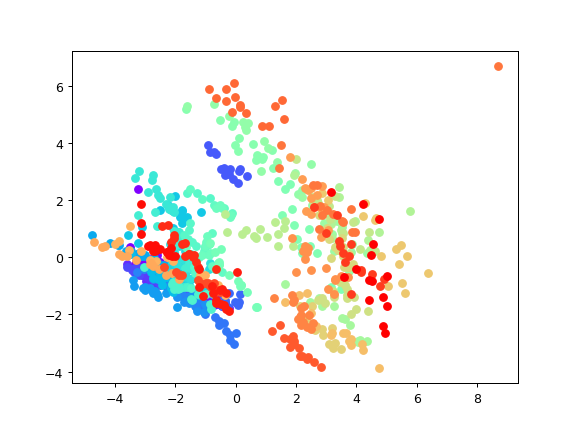

/tmp/ipykernel_4962/3925681469.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_pca[i, 0], X_pca[i,1], 'ro', color = color[y[i]])


In [20]:
from matplotlib.pyplot import cm

color = cm.rainbow(np.linspace(0, 1, int(X.shape[0]/15)))

for i in range(X_pca.shape[0]):
    plt.plot(X_pca[i, 0], X_pca[i,1], 'ro', color = color[y[i]])

### tSNE to check something

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

<IPython.core.display.Javascript object>


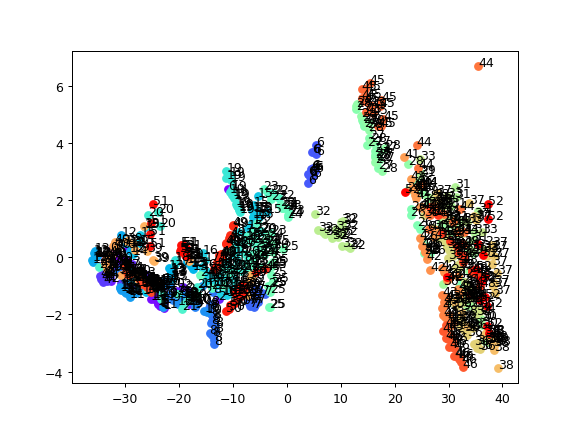

/tmp/ipykernel_4962/3349780567.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X_tsne[i, 0], X_pca[i,1], 'ro', color = color[y[i]])


In [26]:
from matplotlib.pyplot import cm

color = cm.rainbow(np.linspace(0, 1, int(X.shape[0]/15)))

for i in range(X_tsne.shape[0]):
    plt.plot(X_tsne[i, 0], X_pca[i,1], 'ro', color = color[y[i]])
    plt.annotate(y[i], (X_tsne[i, 0], X_pca[i,1]))
# for i, txt in enumerate(n):
#     ax.annotate(txt, (x[i], y[i]))

## Drawing random records from the same group

## Clustering

In [ ]:
ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"],
        random_state=params["random_state"],
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=params["random_state"],
    )
    dbscan = cluster.DBSCAN(eps=params["eps"])
    hdbscan = cluster.HDBSCAN(
        min_samples=params["hdbscan_min_samples"],
        min_cluster_size=params["hdbscan_min_cluster_size"],
        allow_single_cluster=params["allow_single_cluster"],
    )
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"],
        preference=params["preference"],
        random_state=params["random_state"],
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type="full",
        random_state=params["random_state"],
    )

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("HDBSCAN", hdbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )